In [1]:
# Cell 1: Imports & device configuration
import jax

# To force CPU / GPU, uncomment one of these:
# jax.config.update("jax_platform_name", "cpu")
# jax.config.update("jax_platform_name", "gpu")
from jax import vmap

import jax.numpy as jnp
from jax.experimental.ode import odeint
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

In [2]:
# Cell 2: Problem setup & hyperparameters
N = 3               # number of DOFs (you can keep this generic)
T = 3.0
num_steps = 500
ts = jnp.linspace(0.0, T, num_steps)



# Number of coupling springs is N–1
num_couplings = N - 1

# “True” parameters: individual linear (k_i) and nonlinear (alpha_i) stiffnesses
k_true     = jnp.array([10.0 for _ in range(num_couplings)])  # shape (N-1,)
alpha_true = jnp.array([10.0 for _ in range(N)])              # shape (N,)
theta_true = jnp.concatenate([k_true, alpha_true])            # shape (2N-1,)

# Initial guess for each parameter
k_init     = jnp.array([5.0 for _ in range(num_couplings)])
alpha_init = jnp.array([5.0 for _ in range(N)])
theta_true  = jnp.concatenate([k_init, alpha_init])



2025-07-08 03:19:02.161090: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.8.93. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [3]:
# Cell 3: Force model with individual parameters & external/clamp signals
def spring_chain_forces(x, v, theta):
    """
    x: 1D array length N (positions)
    v: 1D array length N (velocities), unused here but kept for interface
    theta: 1D array length 2N–1 = [k_0, ..., k_{N-2}, alpha_0, ..., alpha_{N-1}]
    """
    N = x.shape[0]
    num_couplings = N - 1
    k     = theta[:num_couplings]   # linear spring constants
    alpha = theta[num_couplings:]   # Duffing coefficients

    # linear spring contributions
    f_lin = jnp.zeros_like(x)
    # left boundary spring
    f_lin = f_lin.at[0].set(-k[0] * (x[0] - x[1]))
    # interior springs
    for i in range(1, N-1):
        f_lin = f_lin.at[i].set(
            -k[i]   * (x[i]   - x[i+1])
            -k[i-1] * (x[i]   - x[i-1])
        )
    # right boundary spring
    f_lin = f_lin.at[N-1].set(-k[-1] * (x[-1] - x[-2]))

    # Duffing (cubic) nonlinearity per DOF
    f_duf = -alpha * x**3

    return f_lin + f_duf

vect_spring = vmap(spring_chain_forces, in_axes=(0, 0, None))

def external_force(t):
    return jnp.sin(2 * jnp.pi * t)

def target_x(t):
    return jnp.sin(2 * jnp.pi * t)/4

def target_v(t):
    return 2 * jnp.pi * jnp.cos(2 * jnp.pi * t)/4

In [4]:
spring_chain_forces(jnp.array([10.0, 0.0, 0.0]), jnp.array([0.0, 0.0, 0.0]), theta_true)

Array([-5050.,    50.,    -0.], dtype=float64)

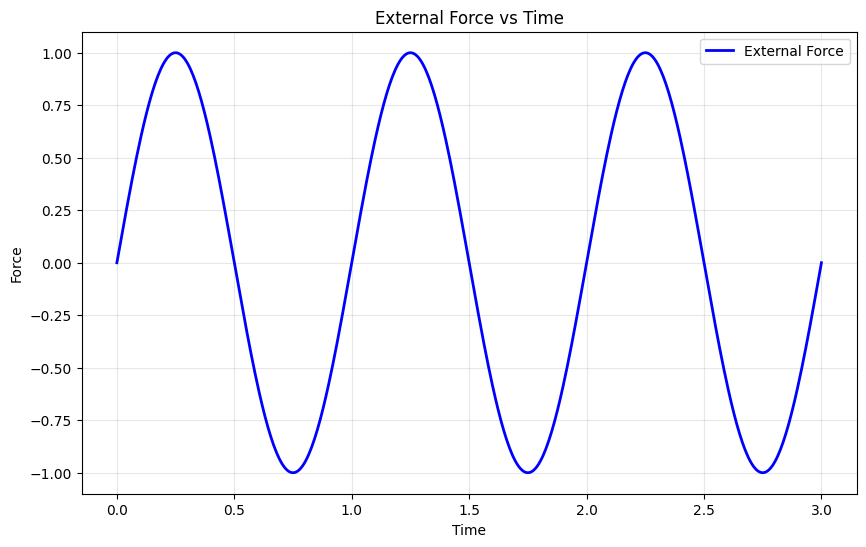

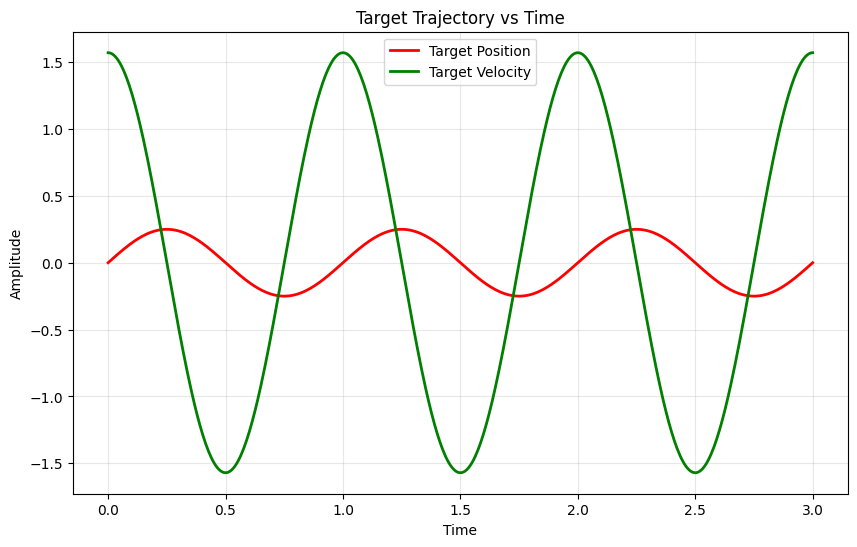

In [5]:
# Cell 6: Plot external force over time T
plt.figure(figsize=(10, 6))
plt.plot(ts, external_force(ts), 'b-', linewidth=2, label='External Force')
plt.xlabel('Time')
plt.ylabel('Force')
plt.title('External Force vs Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Also plot the target trajectory for reference
plt.figure(figsize=(10, 6))
plt.plot(ts, target_x(ts), 'r-', linewidth=2, label='Target Position')
plt.plot(ts, target_v(ts), 'g-', linewidth=2, label='Target Velocity')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Target Trajectory vs Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [6]:
# Cell 4: Clamped dynamics → generate (x,h) & f_target(t)
def clamp_dynamics(state, t, theta):
    # state for DOFs 0..N-2: [x0..x_{N-2}, v0..v_{N-2}]
    n1 = state.shape[0]//2
    x = state[:n1]
    v = state[n1:]
    # extend with clamped last DOF
    x_ext = jnp.concatenate([x, jnp.array([target_x(t)])])
    v_ext = jnp.concatenate([v, jnp.array([target_v(t)])])
    f_int = spring_chain_forces(x_ext, v_ext, theta)
    f_int = f_int.at[0].add(external_force(t))
    a_ext = f_int   # assume M = I
    # only hidden DOFs evolve
    a = a_ext[:n1]
    return jnp.concatenate([v, a])

# integrate the clamped system
init_clamp = jnp.zeros(2*(N-1))
sol_clamp = odeint(clamp_dynamics, init_clamp, ts, theta_true)

# reconstruct full-state & f_target
x_clamp = jnp.concatenate([sol_clamp[:,:N-1], target_x(ts)[:,None]], axis=1)
v_clamp = jnp.concatenate([sol_clamp[:,N-1:], target_v(ts)[:,None]], axis=1)
f_target = vect_spring(x_clamp, v_clamp, theta_true)

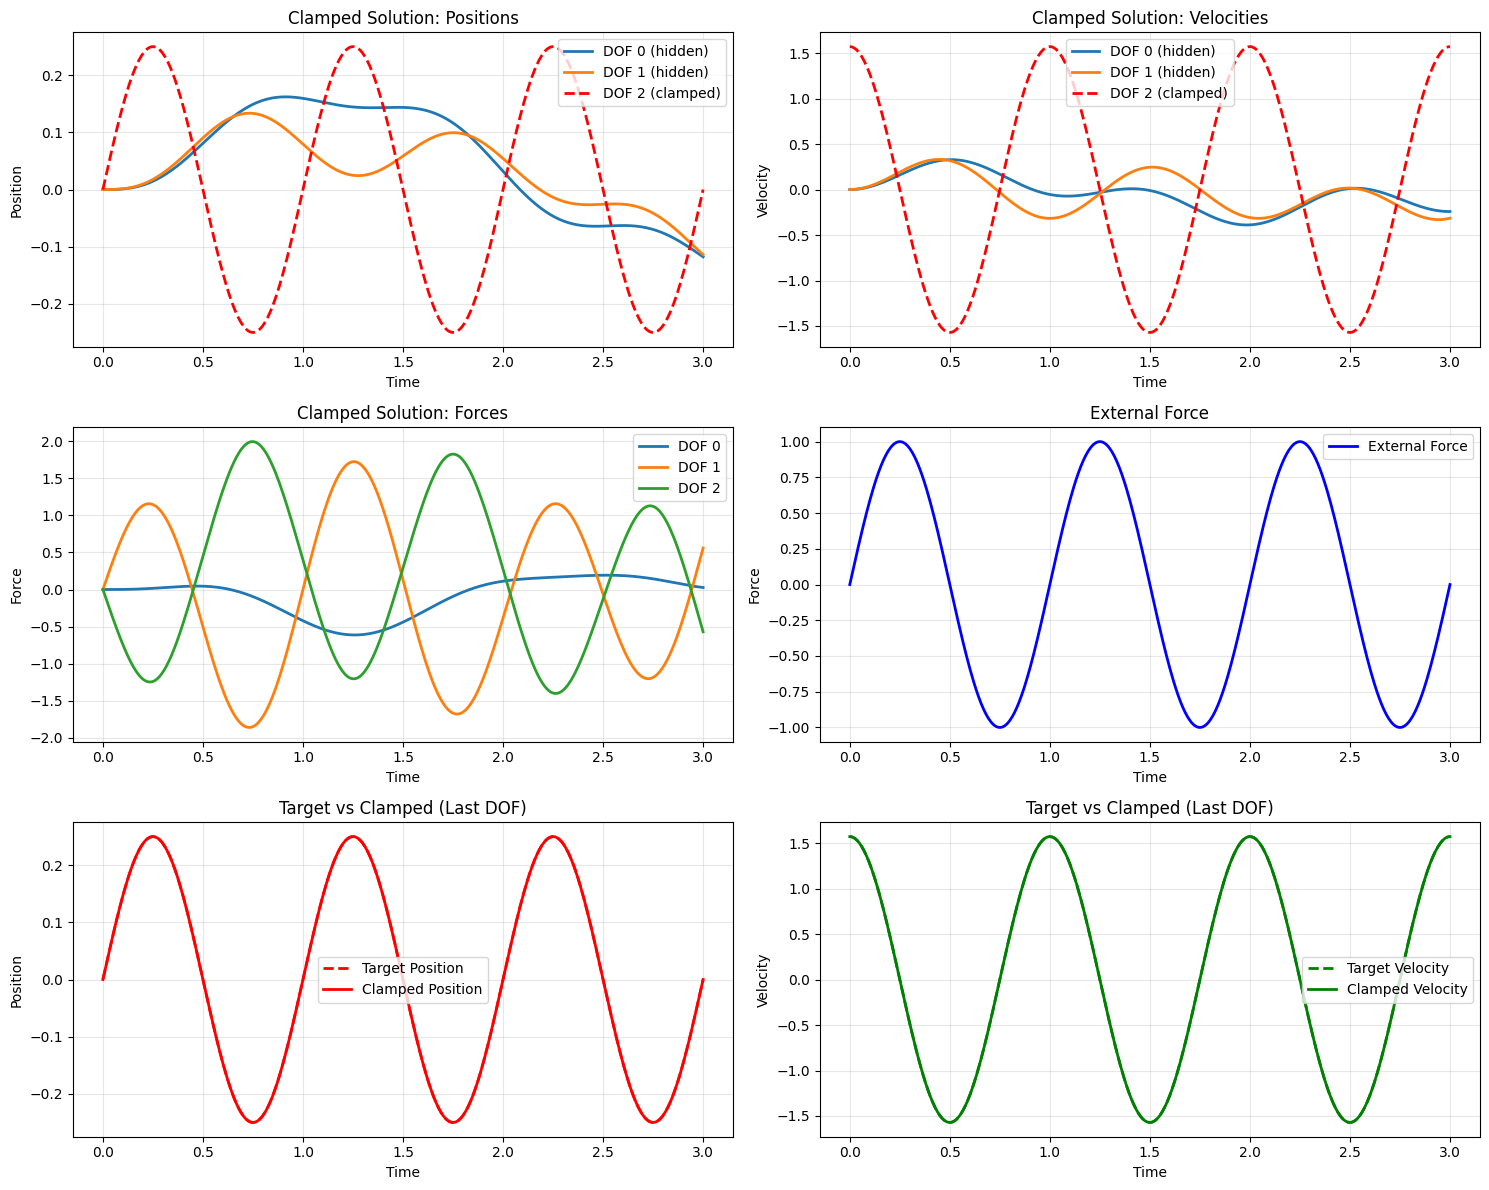

Clamped Solution Statistics:
Number of DOFs: 3
Number of hidden DOFs: 2
Number of clamped DOFs: 1
Time range: 0 to 3.0
Number of time steps: 500
Initial positions: [0. 0. 0.]
Final positions: [-1.17772665e-01 -1.14010822e-01 -1.83697020e-16]
Max force magnitude: 1.9941
Mean force magnitude: 0.6846


In [7]:
# Plot the clamped solution
plt.figure(figsize=(15, 12))

# Plot 1: Positions of all DOFs
plt.subplot(3, 2, 1)
for i in range(N):
    if i < N-1:
        plt.plot(ts, x_clamp[:, i], linewidth=2, label=f'DOF {i} (hidden)')
    else:
        plt.plot(ts, x_clamp[:, i], 'r--', linewidth=2, label=f'DOF {i} (clamped)')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Clamped Solution: Positions')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Velocities of all DOFs
plt.subplot(3, 2, 2)
for i in range(N):
    if i < N-1:
        plt.plot(ts, v_clamp[:, i], linewidth=2, label=f'DOF {i} (hidden)')
    else:
        plt.plot(ts, v_clamp[:, i], 'r--', linewidth=2, label=f'DOF {i} (clamped)')
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.title('Clamped Solution: Velocities')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 3: Forces on all DOFs
plt.subplot(3, 2, 3)
for i in range(N):
    plt.plot(ts, f_target[:, i], linewidth=2, label=f'DOF {i}')
plt.xlabel('Time')
plt.ylabel('Force')
plt.title('Clamped Solution: Forces')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 4: External force
plt.subplot(3, 2, 4)
plt.plot(ts, external_force(ts), 'b-', linewidth=2, label='External Force')
plt.xlabel('Time')
plt.ylabel('Force')
plt.title('External Force')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 5: Target trajectory vs actual clamped trajectory
plt.subplot(3, 2, 5)
plt.plot(ts, target_x(ts), 'r--', linewidth=2, label='Target Position')
plt.plot(ts, x_clamp[:, -1], 'r-', linewidth=2, label='Clamped Position')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Target vs Clamped (Last DOF)')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 6: Target velocity vs actual clamped velocity
plt.subplot(3, 2, 6)
plt.plot(ts, target_v(ts), 'g--', linewidth=2, label='Target Velocity')
plt.plot(ts, v_clamp[:, -1], 'g-', linewidth=2, label='Clamped Velocity')
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.title('Target vs Clamped (Last DOF)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Print some statistics
print("Clamped Solution Statistics:")
print(f"Number of DOFs: {N}")
print(f"Number of hidden DOFs: {N-1}")
print(f"Number of clamped DOFs: 1")
print(f"Time range: 0 to {T}")
print(f"Number of time steps: {num_steps}")
print(f"Initial positions: {x_clamp[0, :]}")
print(f"Final positions: {x_clamp[-1, :]}")
print(f"Max force magnitude: {jnp.max(jnp.abs(f_target)):.4f}")
print(f"Mean force magnitude: {jnp.mean(jnp.abs(f_target)):.4f}") 

In [14]:
# Cell 5: Free dynamics + loss & gradient
def free_dynamics(state, t, theta):
    N2 = state.shape[0]//2
    x = state[:N2]
    v = state[N2:]
    f_int = spring_chain_forces(x, v, theta)
    f_int = f_int.at[0].add(external_force(t))
    a = f_int
    return jnp.concatenate([v, a])

init_free = jnp.zeros(2*N)


def simulate_free(theta):
    sol = odeint(free_dynamics, init_free, ts, theta)
    x   = sol[:, :N]       # shape [num_steps, N]
    v   = sol[:, N:]       # shape [num_steps, N]
    # vectorized force over the entire trajectory:
    f   = vect_spring(x, v, theta)   # shape [num_steps, N]
    return f, x, v

def loss_and_traj(theta):
    f_free, x_free, v_free = simulate_free(theta)
    loss = 0.5 * jnp.mean(jnp.linalg.norm(f_free - f_target, axis=1)**2)
    return loss, f_free, x_free


def grad_loss(theta):
    f_free, x_free, v_free = simulate_free(theta)
    force_theta = lambda th: vect_spring(x_free, v_free, th)
    grad_force_theta = jax.grad(force_theta)
    grad_loss = jnp.mean(jnp.dot(f_free - f_target,grad_force_theta(theta)))
    return grad_loss

In [30]:
f_free, x_free, v_free = simulate_free(theta_true)
force_theta = lambda th: vect_spring(x_free[0,:], v_free[0,:], th)
grad_force_theta = jax.grad(force_theta)

In [33]:
x_free[0,:].shape

(3,)

In [32]:
force_theta(theta_true)

IndexError: tuple index out of range

In [21]:
grad_force_theta(theta_true)

ValueError: Incompatible shapes for broadcasting: shapes=[(0,), (500, 3)]

In [15]:
loss_and_traj(theta_true)

(Array(1.42657881, dtype=float64),
 Array([[-0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
        [-1.13767883e-06,  1.13766403e-06,  1.48006184e-11],
        [-9.09805658e-06,  9.09754046e-06,  5.16114486e-10],
        ...,
        [ 8.70626274e-03, -2.76530567e-01,  2.17151293e-01],
        [ 1.06679745e-02, -2.79654056e-01,  2.18398695e-01],
        [ 1.25841006e-02, -2.82637875e-01,  2.19554352e-01]],      dtype=float64),
 Array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.27538727e-07, 2.96013287e-12, 9.19753841e-18],
        [1.81971462e-06, 1.03309330e-10, 8.64329804e-14],
        ...,
        [1.58665613e-01, 1.64401237e-01, 1.19274146e-01],
        [1.58400399e-01, 1.64508369e-01, 1.19137618e-01],
        [1.58134202e-01, 1.64605393e-01, 1.19008982e-01]], dtype=float64))

In [16]:
grad_loss(theta_true)

ValueError: Incompatible shapes for broadcasting: shapes=[(0,), (500, 3)]

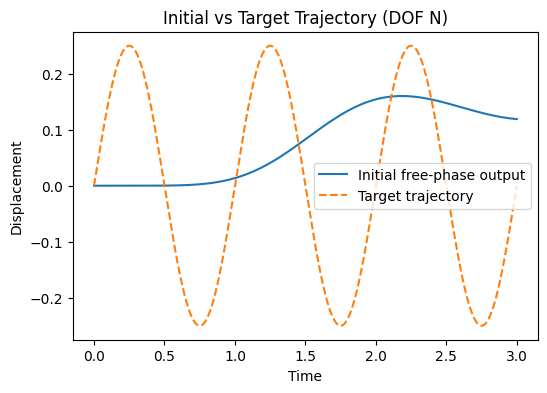

In [11]:

# Simulate the free system with initial parameters
f_init, x_init = simulate_free(theta_true)

# Plot comparison for the last DOF
plt.figure(figsize=(6,4))
plt.plot(ts, x_init[:, -1],    label="Initial free-phase output")
plt.plot(ts, target_x(ts), "--", label="Target trajectory")
plt.title("Initial vs Target Trajectory (DOF N)")
plt.xlabel("Time")
plt.ylabel("Displacement")
plt.legend()
plt.show()

In [12]:
# Initial guess & learning settings
theta_curr     = theta_true
learning_rate = 30.
num_epochs    = 10

# Cell 6: Training loop
loss_history = []
traj_final   = None

for epoch in range(num_epochs):
    print(f"Epoch {epoch} of {num_epochs}")
    grads     = grad_loss(theta_curr)
    theta_curr = theta_curr - learning_rate * grads
    current_loss, _, x_free = loss_and_traj(theta_curr)
    print(f"Current loss: {current_loss}")
    loss_history.append(current_loss)
    if epoch == num_epochs - 1:
        traj_final = x_free

print("Learned theta:", grad_loss)

Epoch 0 of 10
Current loss: nan
Epoch 1 of 10
Current loss: nan
Epoch 2 of 10
Current loss: nan
Epoch 3 of 10
Current loss: nan
Epoch 4 of 10
Current loss: nan
Epoch 5 of 10
Current loss: nan
Epoch 6 of 10
Current loss: nan
Epoch 7 of 10
Current loss: nan
Epoch 8 of 10
Current loss: nan
Epoch 9 of 10
Current loss: nan
Learned theta: <function <lambda> at 0x7ff08041b0a0>


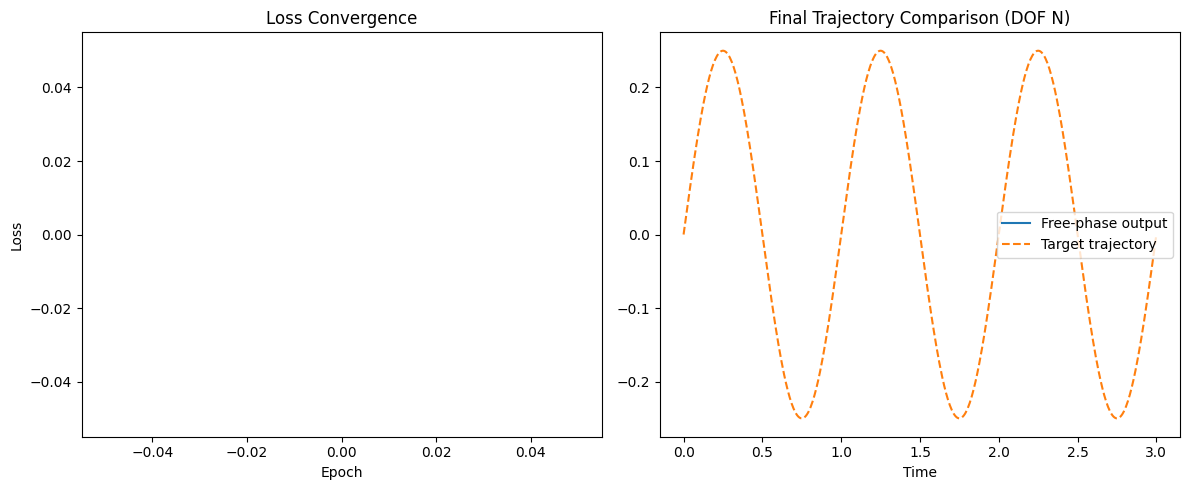

In [13]:
# Cell 7: Plot loss & final trajectory
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(jnp.arange(num_epochs), jnp.array(loss_history))
plt.title("Loss Convergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(ts, traj_final[:,-1], label="Free‐phase output")
plt.plot(ts, target_x(ts), "--",   label="Target trajectory")
plt.title("Final Trajectory Comparison (DOF N)")
plt.xlabel("Time")
plt.legend()

plt.tight_layout()
plt.show()